In [1]:
import io

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import soundfile as sf

from itertools import islice
from datasets import load_dataset, Audio

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix
)

print("EXP-06: Audio Feature Comparison")

c:\Users\Esma Nur Mantı\Desktop\vad-research\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


EXP-06: Audio Feature Comparison


In [2]:
dataset = load_dataset(
    "guynich/librispeech_asr_test_vad",
    split="test.clean",
    streaming=True
)

dataset = dataset.cast_column(
    "audio",
    Audio(decode=False)
)

samples = list(islice(dataset, 30))

records = []

for sample in samples:

    audio_data = sample["audio"]

    if audio_data["bytes"] is not None:
        signal, sr = sf.read(
            io.BytesIO(audio_data["bytes"])
        )
    else:
        signal, sr = sf.read(
            audio_data["path"]
        )

    if signal.ndim > 1:
        signal = signal.mean(axis=1)

    records.append({
        "file": sample["file"],
        "speaker_id": sample["speaker_id"],
        "signal": signal,
        "sr": sr,
        "reference": np.asarray(
            sample["speech"],
            dtype=int
        ),
        "confidence": np.asarray(
            sample["confidence"],
            dtype=int
        )
    })

development_records = records[:15]
evaluation_records = records[15:]

print("Toplam kayıt:", len(records))
print("Geliştirme kayıtları:", len(development_records))
print("Değerlendirme kayıtları:", len(evaluation_records))

Toplam kayıt: 30
Geliştirme kayıtları: 15
Değerlendirme kayıtları: 15


In [3]:
FRAME_MS = 25
HOP_MS = 10
LABEL_MS = 32


def extract_features(signal, sr):

    frame_length = int(
        sr * FRAME_MS / 1000
    )

    hop_length = int(
        sr * HOP_MS / 1000
    )

    # Ses sinyalini pencerelere ayır.
    frames = librosa.util.frame(
        signal,
        frame_length=frame_length,
        hop_length=hop_length
    ).T

    # 1. RMS
    rms = np.sqrt(
        np.mean(frames ** 2, axis=1)
    )

    # 2. ZCR
    zcr = np.mean(
        frames[:, 1:] * frames[:, :-1] < 0,
        axis=1
    )

    # 3. Spectral Centroid
    window = np.hanning(frame_length)

    spectrum = np.abs(
        np.fft.rfft(
            frames * window,
            axis=1
        )
    )

    frequencies = np.fft.rfftfreq(
        frame_length,
        d=1 / sr
    )

    centroid = (
        np.sum(
            spectrum * frequencies,
            axis=1
        )
        /
        np.maximum(
            np.sum(spectrum, axis=1),
            1e-12
        )
    )

    # Üç özelliği tek matriste birleştir.
    features = np.column_stack([
        rms,
        zcr,
        centroid
    ])

    # Her pencerenin merkez zamanı.
    frame_times = (
        np.arange(len(frames)) * hop_length
        + frame_length / 2
    ) / sr

    return features, frame_times

In [4]:
record = development_records[0]

features, frame_times = extract_features(
    record["signal"],
    record["sr"]
)

print("Dosya:", record["file"])

print(
    "Özellik matrisinin boyutu:",
    features.shape
)

print(
    "Zaman dizisinin boyutu:",
    frame_times.shape
)

print("\nİlk 5 frame:")
print(features[:5])

print("\nRMS aralığı:")
print(
    features[:, 0].min(),
    features[:, 0].max()
)

print("\nZCR aralığı:")
print(
    features[:, 1].min(),
    features[:, 1].max()
)

print("\nSpectral Centroid aralığı:")
print(
    features[:, 2].min(),
    features[:, 2].max()
)

Dosya: 6930-75918-0000.flac
Özellik matrisinin boyutu: (349, 3)
Zaman dizisinin boyutu: (349,)

İlk 5 frame:
[[1.32780664e-03 1.65413534e-01 1.87122176e+03]
 [1.03176610e-03 1.65413534e-01 2.21310481e+03]
 [1.05395053e-03 1.42857143e-01 2.15559967e+03]
 [1.03419588e-03 1.70426065e-01 2.25240388e+03]
 [9.57174972e-04 2.58145363e-01 2.40721834e+03]]

RMS aralığı:
0.0007622356983685753 0.0914690294866891

ZCR aralığı:
0.002506265664160401 0.6290726817042607

Spectral Centroid aralığı:
1027.9339556983634 5029.160382100515


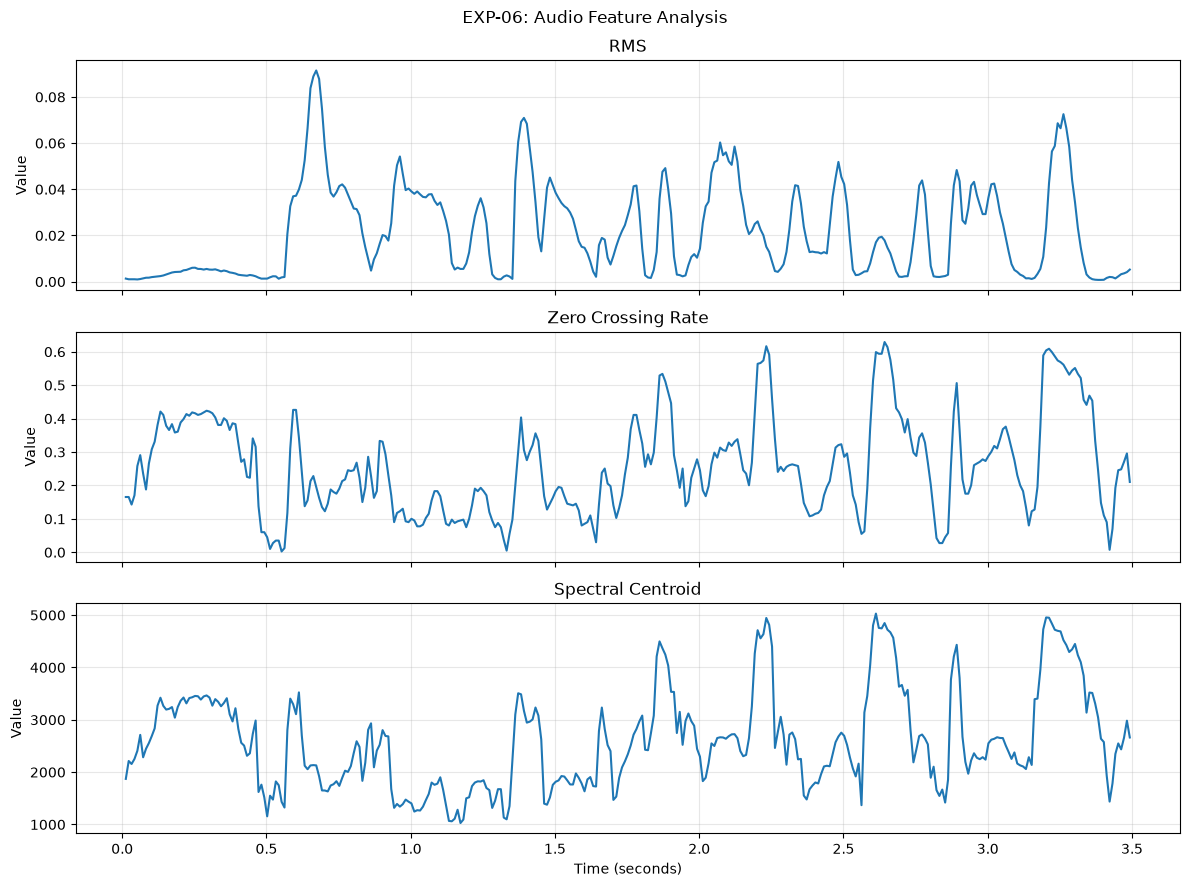

In [5]:
feature_names = [
    "RMS",
    "Zero Crossing Rate",
    "Spectral Centroid"
]

fig, axes = plt.subplots(
    3,
    1,
    figsize=(12, 9),
    sharex=True
)

for i, ax in enumerate(axes):

    ax.plot(
        frame_times,
        features[:, i]
    )

    ax.set_title(feature_names[i])
    ax.set_ylabel("Value")
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Time (seconds)")

plt.suptitle(
    "EXP-06: Audio Feature Analysis"
)

plt.tight_layout()
plt.show()


In [6]:
def align_features(
    features,
    frame_times,
    reference,
    confidence
):

    reference_times = (
        np.arange(len(reference)) + 0.5
    ) * LABEL_MS / 1000

    indices = np.abs(
        frame_times[:, None]
        - reference_times[None, :]
    ).argmin(axis=0)

    aligned_features = features[indices]

    valid = confidence == 1

    X = aligned_features[valid]
    y = reference[valid]

    return X, y

In [7]:
X_list = []
y_list = []

for record in development_records:

    features, frame_times = extract_features(
        record["signal"],
        record["sr"]
    )

    X, y = align_features(
        features,
        frame_times,
        record["reference"],
        record["confidence"]
    )

    X_list.append(X)
    y_list.append(y)

X_dev = np.vstack(X_list)
y_dev = np.concatenate(y_list)

print("X_dev:", X_dev.shape)
print("y_dev:", y_dev.shape)

print(
    "Konuşma etiketi:",
    np.sum(y_dev == 1)
)

print(
    "Konuşma dışı etiketi:",
    np.sum(y_dev == 0)
)

X_dev: (3437, 3)
y_dev: (3437,)
Konuşma etiketi: 3085
Konuşma dışı etiketi: 352


In [8]:
feature_sets = {
    "RMS": [0],
    "RMS + ZCR": [0, 1],
    "RMS + ZCR + Centroid": [0, 1, 2]
}

models = {}

for name, columns in feature_sets.items():

    model = make_pipeline(
        StandardScaler(),
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        )
    )

    model.fit(
        X_dev[:, columns],
        y_dev
    )

    models[name] = model

    print(name, "eğitildi.")

RMS eğitildi.
RMS + ZCR eğitildi.
RMS + ZCR + Centroid eğitildi.


In [9]:
X_list = []
y_list = []

for record in evaluation_records:

    features, frame_times = extract_features(
        record["signal"],
        record["sr"]
    )

    X, y = align_features(
        features,
        frame_times,
        record["reference"],
        record["confidence"]
    )

    X_list.append(X)
    y_list.append(y)

X_eval = np.vstack(X_list)
y_eval = np.concatenate(y_list)

print("X_eval:", X_eval.shape)
print("y_eval:", y_eval.shape)

X_eval: (2816, 3)
y_eval: (2816,)


In [10]:
results = []

for name, columns in feature_sets.items():

    model = models[name]

    prediction = model.predict(
        X_eval[:, columns]
    )

    tn, fp, fn, tp = confusion_matrix(
        y_eval,
        prediction,
        labels=[0, 1]
    ).ravel()

    results.append({
        "Model": name,

        "Precision": precision_score(
            y_eval,
            prediction,
            zero_division=0
        ),

        "Recall": recall_score(
            y_eval,
            prediction,
            zero_division=0
        ),

        "F1": f1_score(
            y_eval,
            prediction,
            zero_division=0
        ),

        "Accuracy": accuracy_score(
            y_eval,
            prediction
        ),

        "TP": tp,
        "TN": tn,
        "FP": fp,
        "FN": fn
    })

results_df = pd.DataFrame(results)

print(
    results_df.round(4).to_string(index=False)
)

               Model  Precision  Recall     F1  Accuracy   TP  TN  FP  FN
                 RMS     0.9906  0.8294 0.9029    0.8391 2105 258  20 433
           RMS + ZCR     0.9906  0.8318 0.9043    0.8413 2111 258  20 427
RMS + ZCR + Centroid     0.9911  0.8325 0.9049    0.8423 2113 259  19 425


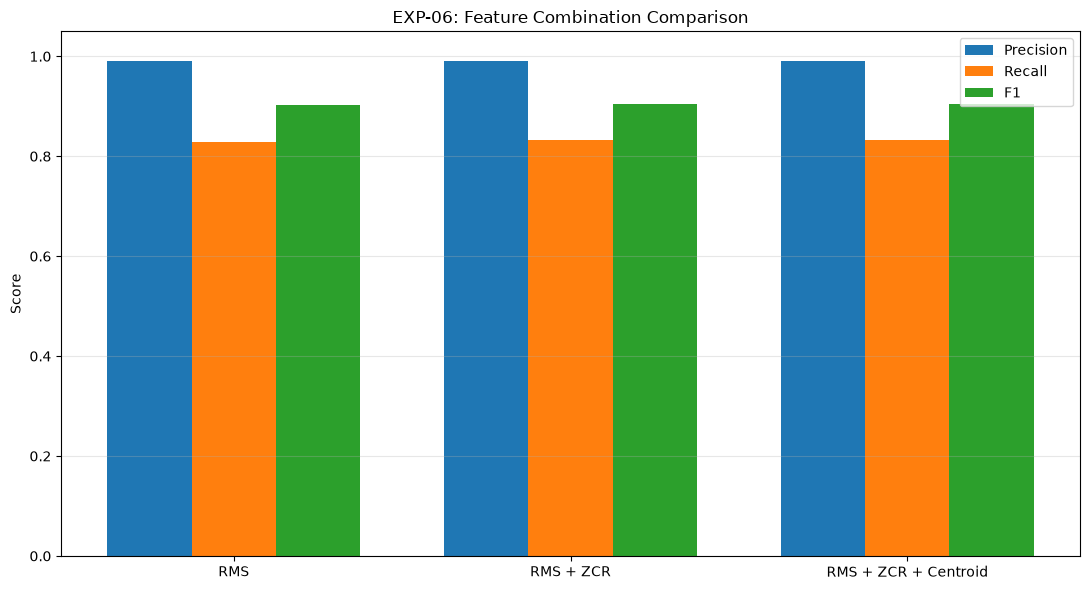

In [11]:
metrics = [
    "Precision",
    "Recall",
    "F1"
]

x = np.arange(len(results_df))
width = 0.25

plt.figure(figsize=(11, 6))

for i, metric in enumerate(metrics):

    plt.bar(
        x + i * width,
        results_df[metric],
        width,
        label=metric
    )

plt.xticks(
    x + width,
    results_df["Model"]
)

plt.ylabel("Score")
plt.title(
    "EXP-06: Feature Combination Comparison"
)

plt.ylim(0, 1.05)
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

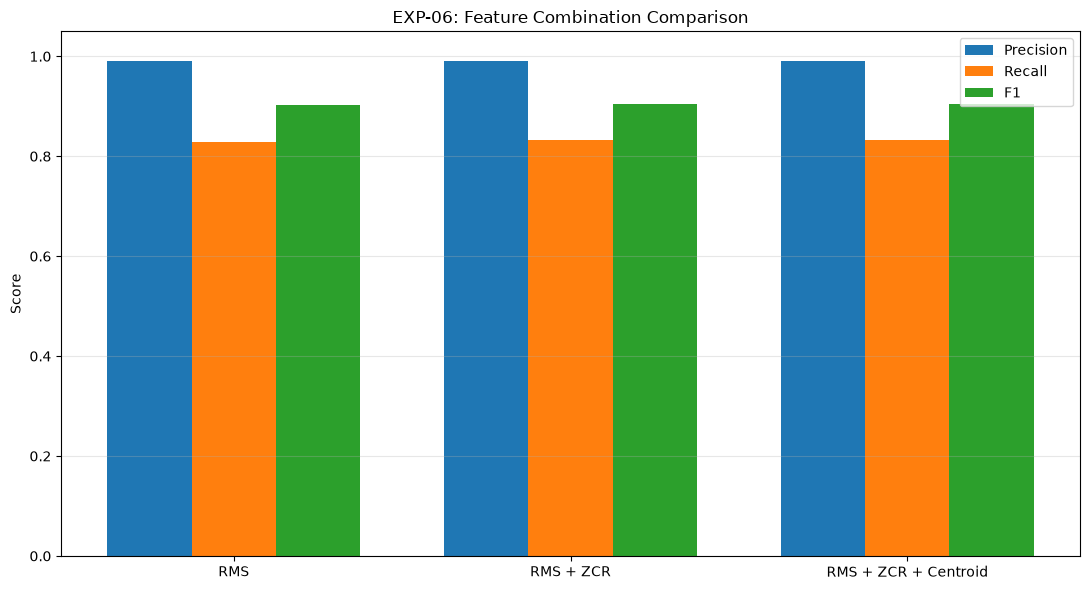

EXP-06 sonuçları kaydedildi.


In [12]:
from pathlib import Path

results_dir = Path("../results")
figures_dir = results_dir / "figures"

results_dir.mkdir(
    parents=True,
    exist_ok=True
)

figures_dir.mkdir(
    parents=True,
    exist_ok=True
)

results_df.to_csv(
    results_dir / "exp06_feature_comparison.csv",
    index=False
)

# Grafiği yeniden oluştur.
fig, ax = plt.subplots(figsize=(11, 6))

for i, metric in enumerate(metrics):

    ax.bar(
        x + i * width,
        results_df[metric],
        width,
        label=metric
    )

ax.set_xticks(x + width)
ax.set_xticklabels(results_df["Model"])
ax.set_ylabel("Score")
ax.set_title(
    "EXP-06: Feature Combination Comparison"
)

ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()

fig.savefig(
    figures_dir / "exp06_feature_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("EXP-06 sonuçları kaydedildi.")

In [13]:
def add_noise(signal, snr_db, seed=42):

    rng = np.random.default_rng(seed)

    noise = rng.normal(0, 1, len(signal))

    signal_power = np.mean(signal ** 2)
    noise_power = np.mean(noise ** 2)

    target_noise_power = signal_power / (
        10 ** (snr_db / 10)
    )

    noise = noise * np.sqrt(
        target_noise_power / noise_power
    )

    return signal + noise

In [14]:
noise_conditions = ["Clean", "20 dB", "10 dB", "0 dB"]

noisy_datasets = {}

for condition in noise_conditions:

    X_list = []
    y_list = []

    for record in evaluation_records:

        signal = record["signal"]

        if condition != "Clean":

            snr_db = int(
                condition.split()[0]
            )

            signal = add_noise(
                signal,
                snr_db
            )

        features, frame_times = extract_features(
            signal,
            record["sr"]
        )

        X, y = align_features(
            features,
            frame_times,
            record["reference"],
            record["confidence"]
        )

        X_list.append(X)
        y_list.append(y)

    noisy_datasets[condition] = {
        "X": np.vstack(X_list),
        "y": np.concatenate(y_list)
    }

    print(
        condition,
        noisy_datasets[condition]["X"].shape
    )

Clean (2816, 3)
20 dB (2816, 3)
10 dB (2816, 3)
0 dB (2816, 3)


In [15]:
noise_results = []

for condition in noise_conditions:

    X_test = noisy_datasets[condition]["X"]
    y_test = noisy_datasets[condition]["y"]

    for name, columns in feature_sets.items():

        model = models[name]

        prediction = model.predict(
            X_test[:, columns]
        )

        tn, fp, fn, tp = confusion_matrix(
            y_test,
            prediction,
            labels=[0, 1]
        ).ravel()

        noise_results.append({
            "Condition": condition,
            "Model": name,

            "Precision": precision_score(
                y_test,
                prediction,
                zero_division=0
            ),

            "Recall": recall_score(
                y_test,
                prediction,
                zero_division=0
            ),

            "F1": f1_score(
                y_test,
                prediction,
                zero_division=0
            ),

            "TP": tp,
            "TN": tn,
            "FP": fp,
            "FN": fn
        })

noise_results_df = pd.DataFrame(
    noise_results
)

print(
    noise_results_df.round(4).to_string(index=False)
)

Condition                Model  Precision  Recall     F1   TP  TN  FP  FN
    Clean                  RMS     0.9906  0.8294 0.9029 2105 258  20 433
    Clean            RMS + ZCR     0.9906  0.8318 0.9043 2111 258  20 427
    Clean RMS + ZCR + Centroid     0.9911  0.8325 0.9049 2113 259  19 425
    20 dB                  RMS     0.9890  0.8491 0.9137 2155 254  24 383
    20 dB            RMS + ZCR     0.9880  0.8455 0.9113 2146 252  26 392
    20 dB RMS + ZCR + Centroid     0.9906  0.8302 0.9033 2107 258  20 431
    10 dB                  RMS     0.9139  0.9953 0.9528 2526  40 238  12
    10 dB            RMS + ZCR     0.9245  0.9898 0.9560 2512  73 205  26
    10 dB RMS + ZCR + Centroid     0.9249  0.9854 0.9542 2501  75 203  37
     0 dB                  RMS     0.9013  1.0000 0.9481 2538   0 278   0
     0 dB            RMS + ZCR     0.9013  1.0000 0.9481 2538   0 278   0
     0 dB RMS + ZCR + Centroid     0.9013  1.0000 0.9481 2538   0 278   0


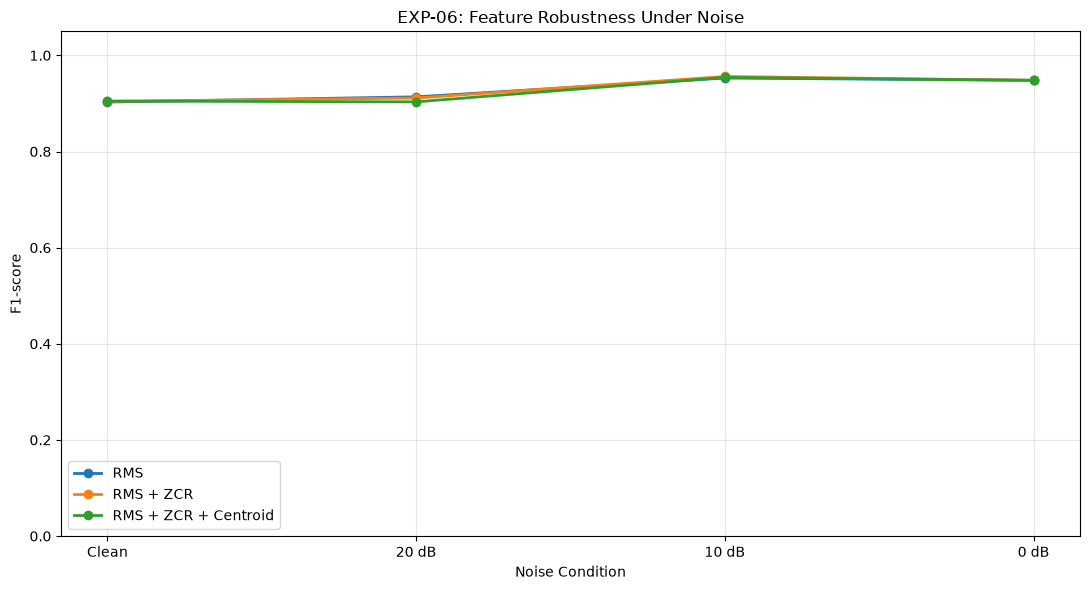

In [16]:
plt.figure(figsize=(11, 6))

for name in feature_sets:

    subset = noise_results_df[
        noise_results_df["Model"] == name
    ]

    plt.plot(
        subset["Condition"],
        subset["F1"],
        marker="o",
        linewidth=2,
        label=name
    )

plt.title(
    "EXP-06: Feature Robustness Under Noise"
)

plt.xlabel("Noise Condition")
plt.ylabel("F1-score")

plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [17]:
error_df = noise_results_df[
    [
        "Condition",
        "Model",
        "Precision",
        "Recall",
        "F1",
        "TP",
        "TN",
        "FP",
        "FN"
    ]
]

print(
    error_df.round(4).to_string(index=False)
)

Condition                Model  Precision  Recall     F1   TP  TN  FP  FN
    Clean                  RMS     0.9906  0.8294 0.9029 2105 258  20 433
    Clean            RMS + ZCR     0.9906  0.8318 0.9043 2111 258  20 427
    Clean RMS + ZCR + Centroid     0.9911  0.8325 0.9049 2113 259  19 425
    20 dB                  RMS     0.9890  0.8491 0.9137 2155 254  24 383
    20 dB            RMS + ZCR     0.9880  0.8455 0.9113 2146 252  26 392
    20 dB RMS + ZCR + Centroid     0.9906  0.8302 0.9033 2107 258  20 431
    10 dB                  RMS     0.9139  0.9953 0.9528 2526  40 238  12
    10 dB            RMS + ZCR     0.9245  0.9898 0.9560 2512  73 205  26
    10 dB RMS + ZCR + Centroid     0.9249  0.9854 0.9542 2501  75 203  37
     0 dB                  RMS     0.9013  1.0000 0.9481 2538   0 278   0
     0 dB            RMS + ZCR     0.9013  1.0000 0.9481 2538   0 278   0
     0 dB RMS + ZCR + Centroid     0.9013  1.0000 0.9481 2538   0 278   0


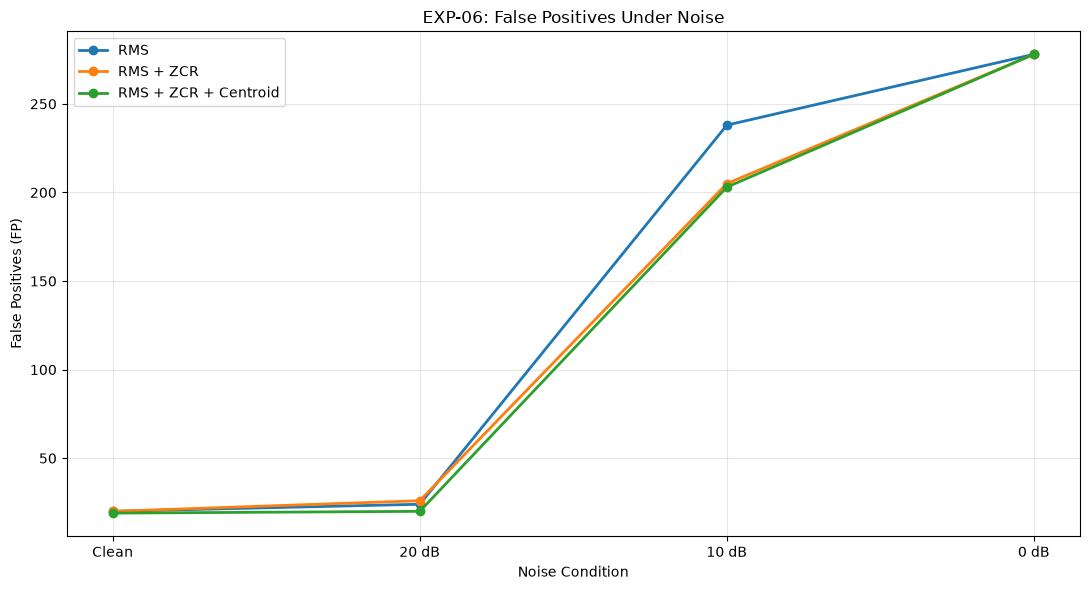

In [18]:
plt.figure(figsize=(11, 6))

for name in feature_sets:

    subset = noise_results_df[
        noise_results_df["Model"] == name
    ]

    plt.plot(
        subset["Condition"],
        subset["FP"],
        marker="o",
        linewidth=2,
        label=name
    )

plt.title(
    "EXP-06: False Positives Under Noise"
)

plt.xlabel("Noise Condition")
plt.ylabel("False Positives (FP)")

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [19]:
noise_results_df["Specificity"] = (
    noise_results_df["TN"]
    /
    (
        noise_results_df["TN"]
        + noise_results_df["FP"]
    )
)

print(
    noise_results_df[
        [
            "Condition",
            "Model",
            "F1",
            "Specificity",
            "FP",
            "FN"
        ]
    ].round(4).to_string(index=False)
)

Condition                Model     F1  Specificity  FP  FN
    Clean                  RMS 0.9029       0.9281  20 433
    Clean            RMS + ZCR 0.9043       0.9281  20 427
    Clean RMS + ZCR + Centroid 0.9049       0.9317  19 425
    20 dB                  RMS 0.9137       0.9137  24 383
    20 dB            RMS + ZCR 0.9113       0.9065  26 392
    20 dB RMS + ZCR + Centroid 0.9033       0.9281  20 431
    10 dB                  RMS 0.9528       0.1439 238  12
    10 dB            RMS + ZCR 0.9560       0.2626 205  26
    10 dB RMS + ZCR + Centroid 0.9542       0.2698 203  37
     0 dB                  RMS 0.9481       0.0000 278   0
     0 dB            RMS + ZCR 0.9481       0.0000 278   0
     0 dB RMS + ZCR + Centroid 0.9481       0.0000 278   0
